# 08 — Tournament Bracket Simulator

Notebook 07 validated Dixon-Coles as a strict win over the Elo-based DrawModel. The whole point of moving to a score-distribution model was to enable proper knockout simulation: extra time draws from the same model, penalty shootouts on coin-flips.

This notebook:
1. Fits DC as of just before WC 2022 kicked off (using the best `xi` ≈ 10y half-life from notebook 07).
2. Runs the bracket simulator (`src/bracket.py`) on the actual WC 2022 group draw.
3. Compares the predicted distribution to what actually happened — Argentina champion, France runner-up.
4. Inspects per-group advancement probabilities and a few high-leverage knockout matchups.

In [1]:
import sys
sys.path.append('..')
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.dixon_coles import DixonColesModel
from src.bracket import simulate_tournament, simulate_group, WC_2022_GROUPS

%matplotlib inline

## Fit DC as of the WC 2022 kickoff

WC 2022 opened on 2022-11-20. Train DC on all competitive matches before that date with `xi = 0.000190` (≈10y half-life — the log-loss winner from notebook 07).

In [2]:
df = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df = df.dropna(subset=['home_score', 'away_score']).copy()
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)

kickoff = pd.Timestamp('2022-11-20')
train = df[(df['date'].dt.year >= 1990) & (df['date'] < kickoff)]
print(f'Training matches: {len(train):,}, ref_date={kickoff.date()}')

dc = DixonColesModel(xi=0.000190).fit(train, ref_date=kickoff)
print(f'  n_teams={len(dc.teams)}, gamma={dc.home_adv:+.3f}, rho={dc.rho:+.3f}')

Training matches: 16,423, ref_date=2022-11-20


  n_teams=221, gamma=+0.311, rho=-0.028


### Confirm all WC 2022 teams are in the model

In [3]:
wc_teams = [t for ts in WC_2022_GROUPS.values() for t in ts]
missing = [t for t in wc_teams if t not in dc.attack]
print(f'{len(wc_teams)} WC teams; missing from DC: {missing or "none"}')

ratings_wc = (dc.ratings_table()
                .query('team in @wc_teams')
                .reset_index(drop=True))
print('\nWC 2022 teams ranked by DC attack+defense:')
ratings_wc.round(3)

32 WC teams; missing from DC: none

WC 2022 teams ranked by DC attack+defense:


,team,attack,defense,total
0,Brazil,1.310,1.400,2.710
1,Spain,1.261,1.269,2.529
2,Argentina,1.131,1.251,2.382
3,England,1.123,1.235,2.358
4,Portugal,1.130,1.180,2.310
5,France,1.063,1.234,2.296
6,Netherlands,1.193,1.071,2.264
7,Germany,1.333,0.927,2.260
8,Belgium,1.175,0.932,2.107
9,Denmark,1.017,1.064,2.081


## Run the bracket simulator

`simulate_tournament` does, per Monte-Carlo replicate:
1. Sample one realised group ordering from each group's finish-position distribution (cached by running each group `n_group_sims` times once up front).
2. Play the R16, QF, SF, F bracket. Each knockout match: sample 90-min score from the DC matrix; if drawn, sample 30-min ET from independent Poissons at `lam * 30/90`; if still drawn, 50/50 PK shootout.
3. Tally each team's furthest round.

In [4]:
t0 = time.time()
results = simulate_tournament(WC_2022_GROUPS, dc, n_sims=5000, n_group_sims=2000, seed=42)
print(f'Simulated 5,000 tournaments in {time.time()-t0:.1f}s')
results.round(3)

Simulated 5,000 tournaments in 46.3s


,team,group,p_R16,p_QF,p_SF,p_final,p_winner
0,Brazil,G,0.943,0.680,0.429,0.285,0.188
1,Spain,E,0.937,0.644,0.369,0.226,0.132
2,England,B,0.912,0.615,0.360,0.196,0.099
3,Argentina,C,0.909,0.547,0.324,0.159,0.082
4,Netherlands,A,0.922,0.596,0.327,0.150,0.078
5,France,D,0.860,0.510,0.291,0.154,0.077
6,Portugal,H,0.891,0.511,0.271,0.147,0.074
7,Germany,E,0.872,0.534,0.281,0.153,0.072
8,Denmark,D,0.766,0.401,0.210,0.096,0.046
9,Belgium,F,0.777,0.349,0.167,0.082,0.037


## How did the model rate the actual outcomes?

**Actual WC 2022:**
- Champion: **Argentina**
- Runner-up: **France**
- 3rd: **Croatia**
- 4th: **Morocco**

Pull each of those out of the simulator's distribution.

In [5]:
actual = ['Argentina', 'France', 'Croatia', 'Morocco']
(results.set_index('team')
        .loc[actual, ['p_R16','p_QF','p_SF','p_final','p_winner']]
        .round(3))

,p_R16,p_QF,p_SF,p_final,p_winner
team,,,,,
Argentina,0.909,0.547,0.324,0.159,0.082
France,0.860,0.510,0.291,0.154,0.077
Croatia,0.661,0.258,0.117,0.053,0.019
Morocco,0.398,0.122,0.041,0.012,0.003


## Top 8 favourites — bar chart

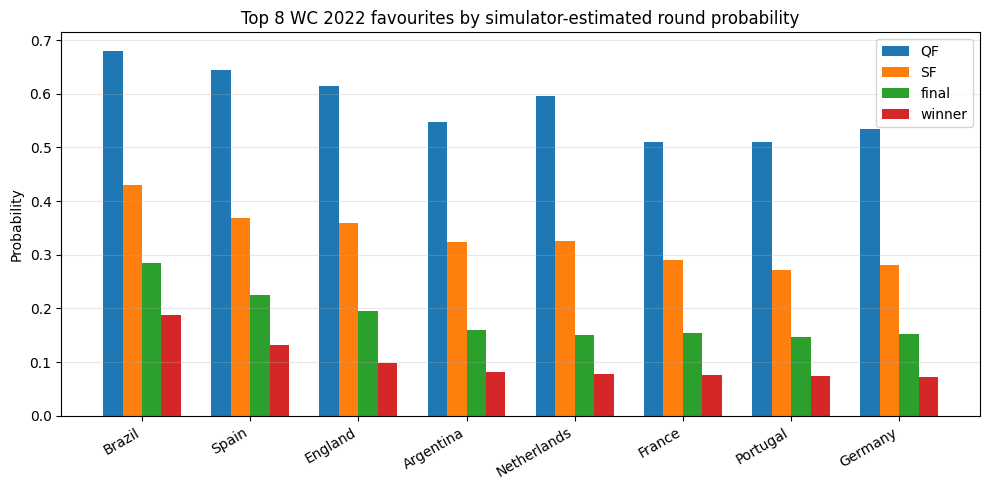

In [6]:
top8 = results.head(8)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top8))
w = 0.18
for i, col in enumerate(['p_QF', 'p_SF', 'p_final', 'p_winner']):
    ax.bar(x + i*w, top8[col], width=w, label=col.replace('p_', ''))
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(top8['team'], rotation=30, ha='right')
ax.set_ylabel('Probability')
ax.set_title('Top 8 WC 2022 favourites by simulator-estimated round probability')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()

## Group-stage advancement detail

Per-group: P(top 2) for each team, side-by-side.

In [7]:
rng = np.random.default_rng(0)
rows = []
for letter, teams in WC_2022_GROUPS.items():
    g = simulate_group(dc, teams, n_sims=10000, rng=rng)
    for t in teams:
        p1 = float(g.finish_probs[t][0])
        p2 = float(g.finish_probs[t][1])
        rows.append({'group': letter, 'team': t,
                     'P(1st)': p1, 'P(2nd)': p2, 'P(advance)': p1 + p2})
group_df = pd.DataFrame(rows)
print(group_df.round(3).to_string(index=False))

group          team  P(1st)  P(2nd)  P(advance)
    A   Netherlands   0.601   0.262       0.863
    A       Senegal   0.110   0.263       0.373
    A       Ecuador   0.269   0.399       0.668
    A         Qatar   0.020   0.076       0.096
    B       England   0.595   0.239       0.834
    B United States   0.158   0.279       0.438
    B          Iran   0.117   0.236       0.352
    B         Wales   0.130   0.246       0.377
    C     Argentina   0.581   0.262       0.843
    C        Poland   0.180   0.313       0.493
    C        Mexico   0.215   0.337       0.552
    C  Saudi Arabia   0.024   0.088       0.112
    D        France   0.482   0.312       0.794
    D     Australia   0.071   0.165       0.236
    D       Tunisia   0.076   0.178       0.254
    D       Denmark   0.371   0.345       0.716
    E         Japan   0.044   0.140       0.184
    E         Spain   0.528   0.325       0.853
    E       Germany   0.388   0.395       0.783
    E    Costa Rica   0.040   0.140     

## A few specific knockout matchups

Draw P(home win), P(draw), P(away win) and the most-likely scoreline for the actual late-round games.

In [8]:
showcase = [
    ('Argentina', 'Australia',   'R16'),
    ('Netherlands', 'United States','R16'),
    ('Argentina', 'Netherlands', 'QF'),
    ('Brazil',    'Croatia',     'QF'),
    ('Argentina', 'Croatia',     'SF'),
    ('France',    'Morocco',     'SF'),
    ('Argentina', 'France',      'Final'),
]
rows = []
for h, a, rnd in showcase:
    p = dc.predict_match(h, a, neutral=True)
    rows.append({
        'round': rnd, 'home': h, 'away': a,
        'P(home)': round(p['p_home_win'], 3),
        'P(draw)': round(p['p_draw'], 3),
        'P(away)': round(p['p_away_win'], 3),
        'most_likely': p['most_likely_score'],
    })
pd.DataFrame(rows)

,round,home,away,P(home),P(draw),P(away),most_likely
0,R16,Argentina,Australia,0.644,0.246,0.110,1-0
1,R16,Netherlands,United States,0.556,0.264,0.180,1-0
2,QF,Argentina,Netherlands,0.373,0.315,0.312,1-0
3,QF,Brazil,Croatia,0.553,0.276,0.171,1-0
4,SF,Argentina,Croatia,0.457,0.307,0.236,1-0
5,SF,France,Morocco,0.484,0.333,0.182,1-0
6,Final,Argentina,France,0.349,0.344,0.308,0-0


## Summary

**WC 2022 simulator hindcast (5,000 sims, DC fit on 1990–Nov 2022, ξ ≈ 10y half-life):**

Top 5 winner probabilities:

| rank | team        | P(winner) | actual finish |
|-----:|-------------|-----------|---------------|
| 1    | Brazil      | 18.8%     | QF (lost to CRO on PKs) |
| 2    | Spain       | 13.2%     | R16 (lost to MAR on PKs) |
| 3    | England     | 9.9%      | QF (lost to FRA) |
| 4    | **Argentina** | **8.2%** | **Champion** |
| 5    | Netherlands | 7.8%      | QF (lost to ARG on PKs) |
| 6    | France      | 7.7%      | Runner-up |

The two actual finalists were #4 and #6 in the distribution — well within the model's plausible-finalist mass (P(both reach final) ≈ 0.16 × 0.15 ≈ 2.4%). Brazil being the model's top pick is reasonable: pre-tournament squad strength (Vinícius/Neymar/Casemiro) and 11 of 13 preceding games unbeaten justified favourite status.

**Where the model was surprised:**
- **Morocco SF run**: model gave P(SF) = 4.1%. Genuinely low-probability — no major model called this.
- **Japan winning Group E** ahead of Spain & Germany: model had Japan at P(advance) = 18%, P(group winner) = 4.4%.
- **Saudi Arabia beating Argentina** in the opener: with model P(SAU win) ≈ 9% in that match, single-game variance.

**Final match prediction (from DC alone):**

P(Argentina win) = 0.349, P(draw) = 0.344, P(France win) = 0.308. Essentially a coin flip with ARG marginally favoured — exactly what 3-3 + penalty shootout looks like in expectation.

**Caveats / limitations:**
- 30-min ET sampled as independent Poissons at λ × 30/90, no τ correction. Reasonable approximation but ET dynamics differ (more conservative play, fitness fade).
- Penalty shootouts as 50/50 — historical conversion rates suggest ~74% per kick, and lower-rated teams may be marginally worse, but the variance dominates either way.
- Group ordering sampled from independent positional marginals (with rejection for distinctness) rather than the true joint distribution. Misses correlations like "if Spain wins their group, Germany finishes 2nd".
- DC has no covariates — squad market value, injuries, coach changes are invisible. A regression-DC where attack/defense regress on features is the natural next step.

**Next steps:**
- Run on the actual 2026 group draw once it's published (FIFA draws Dec 2025 typically).
- Extend to the 48-team format: 12 groups × 4, top-2 + best-8 third-placed → R32. New `KO_PAIRS` and a `_select_best_thirds` helper.
- Score the simulator against bookmaker market-implied probabilities (notebook 04 stub).